# 03. Regularization, derived

**The problem:** ordinary least squares picks whatever $w$ fits the training data best, including
coefficients that are huge because they happen to cancel noise. Regularization adds a price for size
to the loss, so a coefficient has to earn its magnitude.

| symbol | code name | what it is |
|---|---|---|
| $\lambda$ | `lam` | "lambda," the regularization strength. sklearn calls it `alpha`. 0 = no penalty |
| $\|w\|_2^2 = \sum_j w_j^2$ | `np.sum(w**2)` | the squared L2 norm: sum of squared weights |
| $\|w\|_1 = \sum_j |w_j|$ | `np.sum(np.abs(w))` | the L1 norm: sum of absolute weights |
| $I$ | `np.eye(p)` | the identity matrix |

The bias $b$ is never penalized; it just sets the baseline level.

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DB = "C:/Users/palla/OneDrive/Documents/Coding Projects/cheatsheets_and_templates/Homework/homework.sqlite"
con = sqlite3.connect(DB)
def q(sql):
    """Run SQL against homework.sqlite and return a DataFrame."""
    return pd.read_sql(sql, con)

SEED = 42
rng = np.random.default_rng(SEED)
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})
BLUE, ORANGE, GRAY = "#2a78d6", "#eb6834", "#9a9a94"

## 1. Ridge: the L2 penalty

$$L_{\text{ridge}}(w, b) = \underbrace{\frac{1}{n}\sum_{i}(y_i - x_i\cdot w - b)^2}_{\text{fit}} \;+\; \underbrace{\lambda \sum_{j} w_j^2}_{\text{size}}$$

The gradient picks up one extra term, because $\frac{\partial}{\partial w_j}\lambda w_j^2 = 2\lambda w_j$:

$$\nabla_w L_{\text{ridge}} = -\frac{2}{n}X^{\top}(y - \hat{y}) + 2\lambda w$$

Read the new term: every step, each weight gets pulled toward zero by an amount proportional to
its own size. Big weights get pulled hard, small weights barely. A weight near zero is nearly free,
which is why ridge **shrinks but never zeroes**.

Set the gradient to zero (with the ones column folded in and $b$ left unpenalized by zeroing the
first diagonal entry of $I$) and the closed form is:

$$\hat{w}_{\text{ridge}} = (X^{\top}X + n\lambda I)^{-1}X^{\top}y$$

Adding $n\lambda I$ to the diagonal is also what makes the matrix invertible when $X^{\top}X$ is not
(perfectly correlated features, or $p > n$). That is where the name comes from: it adds a "ridge"
along the diagonal.

**What this cell does:** loads the diabetes table with five noise columns, standardizes, and fits ridge
by the closed form across several $\lambda$, then checks against `Ridge`.

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso

diabetes = q("""
SELECT age, sex, bmi, bp, s1, s2, s3, s4, s5, s6,
       random() / 9223372036854775807.0 AS noise_1,
       random() / 9223372036854775807.0 AS noise_2,
       random() / 9223372036854775807.0 AS noise_3,
       disease_progression
FROM diabetes
""")
feature_names = [c for c in diabetes.columns if c != "disease_progression"]
X_raw, y = diabetes[feature_names].to_numpy(), diabetes["disease_progression"].to_numpy()
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.3, random_state=SEED)
scaler = StandardScaler().fit(X_train_raw)
X_train, X_test = scaler.transform(X_train_raw), scaler.transform(X_test_raw)
n_rows, n_features = X_train.shape

def ridge_closed_form(X, y, lam):
    """w = (X^T X + n lam I)^-1 X^T y, with the intercept folded in and left unpenalized."""
    X_ones = np.column_stack([np.ones(len(X)), X])
    penalty = len(X) * lam * np.eye(X_ones.shape[1])
    penalty[0, 0] = 0.0                                   # do not penalize the intercept
    w_full = np.linalg.solve(X_ones.T @ X_ones + penalty, X_ones.T @ y)
    return w_full[1:], w_full[0]

def rmse(y, y_hat): return np.sqrt(np.mean((y - y_hat) ** 2))

print(f"{'lambda':>8} {'test RMSE':>10} {'max |w|':>9} {'sklearn max |w|':>16}")
for lam in [0.0, 0.01, 0.1, 1.0, 10.0]:
    w_hand, b_hand = ridge_closed_form(X_train, y_train, lam)
    # sklearn's Ridge minimizes ||y - Xw||^2 + alpha ||w||^2 (no 1/n), so alpha = n * lam.
    library = Ridge(alpha=n_rows * lam).fit(X_train, y_train)
    print(f"{lam:>8} {rmse(y_test, X_test @ w_hand + b_hand):>10.2f} {np.abs(w_hand).max():>9.2f} {np.abs(library.coef_).max():>16.2f}")

  lambda  test RMSE   max |w|  sklearn max |w|
     0.0      54.01     45.04            45.04
    0.01      53.87     26.84            26.84
     0.1      53.52     25.28            25.28
     1.0      54.72     15.59            15.59
    10.0      65.96      3.79             3.79


## 2. Lasso: the L1 penalty, and why it produces exact zeros

$$L_{\text{lasso}}(w, b) = \frac{1}{n}\sum_{i}(y_i - x_i\cdot w - b)^2 \;+\; \lambda \sum_{j} |w_j|$$

The derivative of $|w_j|$ is $+\lambda$ when $w_j > 0$ and $-\lambda$ when $w_j < 0$: a **constant
pull toward zero that does not shrink as the weight gets small**. Under ridge the pull was
$2\lambda w_j$, which fades to nothing near zero. Under lasso the pull is $\lambda$ all the way down,
so a weak weight gets dragged to exactly zero and pinned there.

There is no closed form because $|w_j|$ has a corner at zero. The standard solver is
**coordinate descent**: fix every weight but one, solve for that one exactly, rotate through
all of them, repeat. For a single weight $w_j$ with standardized features, the exact update is a
**soft threshold**:

$$\rho_j = \frac{1}{n}\sum_i x_{ij}\big(y_i - b - \textstyle\sum_{k \ne j} x_{ik} w_k\big)
\qquad
w_j \leftarrow \text{sign}(\rho_j)\,\max\!\big(|\rho_j| - \tfrac{\lambda}{2},\, 0\big)$$

$\rho_j$ is "how much feature $j$ correlates with what is left to explain." If that correlation
is smaller than $\lambda/2$ in absolute value, the weight is set to zero. Otherwise it is kept,
shrunk by $\lambda/2$. That max-with-zero is the whole reason lasso selects features.

**What this cell does:** implements coordinate descent with soft thresholding and checks it against `Lasso`.

In [3]:
def soft_threshold(rho, threshold):
    """sign(rho) * max(|rho| - threshold, 0): the lasso update for one weight."""
    return np.sign(rho) * np.maximum(np.abs(rho) - threshold, 0.0)

def lasso_coordinate_descent(X, y, lam, n_sweeps=200):
    """Cycle through weights, solving each one exactly while the others stay fixed."""
    n_rows, n_features = X.shape
    w = np.zeros(n_features)
    b = y.mean()                                            # intercept: mean of y on standardized X
    column_scale = np.sum(X ** 2, axis=0) / n_rows          # (1/n) sum x_ij^2, equals 1 after standardizing
    for sweep in range(n_sweeps):
        for j in range(n_features):
            residual_without_j = y - b - X @ w + X[:, j] * w[j]    # what is left to explain if w_j were 0
            rho = (X[:, j] @ residual_without_j) / n_rows
            w[j] = soft_threshold(rho, lam / 2.0) / column_scale[j]
    return w, b

print(f"{'lambda':>8} {'test RMSE':>10} {'zeros (hand)':>13} {'zeros (sklearn)':>16}")
for lam in [0.5, 2.0, 5.0, 10.0, 30.0]:
    w_hand, b_hand = lasso_coordinate_descent(X_train, y_train, lam)
    # sklearn's Lasso minimizes (1/2n)||y - Xw||^2 + alpha ||w||_1, so alpha = lam / 2.
    library = Lasso(alpha=lam / 2.0, max_iter=50000).fit(X_train, y_train)
    print(f"{lam:>8} {rmse(y_test, X_test @ w_hand + b_hand):>10.2f} {int(np.sum(w_hand == 0)):>13} {int(np.sum(library.coef_ == 0)):>16}")

w_hand, _ = lasso_coordinate_descent(X_train, y_train, 5.0)
library = Lasso(alpha=2.5, max_iter=50000).fit(X_train, y_train)
print("\nweights at lambda = 5:")
print(pd.DataFrame({"by_hand": w_hand, "sklearn": library.coef_}, index=feature_names).round(2))

  lambda  test RMSE  zeros (hand)  zeros (sklearn)
     0.5      53.79             0                0
     2.0      53.47             2                2
     5.0      53.15             5                5
    10.0      53.09             8                8
    30.0      55.74             9                9



weights at lambda = 5:
         by_hand  sklearn
age         0.00     0.00
sex        -7.60    -7.60
bmi        26.85    26.85
bp         15.98    15.98
s1         -1.97    -1.97
s2         -0.00    -0.00
s3        -13.01   -13.01
s4          0.00     0.00
s5         17.05    17.05
s6          1.10     1.10
noise_1    -0.00    -0.00
noise_2    -2.20    -2.20
noise_3    -0.00    -0.00


## 3. The picture behind "L1 zeroes, L2 does not"

Minimizing fit plus penalty is the same as minimizing fit subject to a budget on the penalty.
The budget shapes are a circle for L2 ($w_1^2 + w_2^2 \le c$) and a diamond for L1 ($|w_1| + |w_2| \le c$).
The fit's contours are ellipses around the unpenalized optimum. The solution is where an ellipse first
touches the budget shape. A circle gets touched on its curved edge, almost never where a coordinate is
zero. A diamond gets touched at a corner most of the time, and a corner is exactly where one weight is zero.

**What this cell does:** draws it.

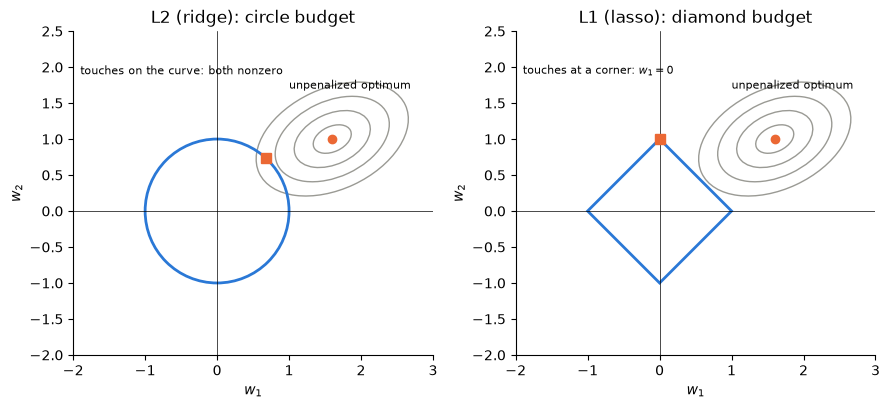

In [4]:
from matplotlib.patches import Circle, Polygon, Ellipse

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
optimum = np.array([1.6, 1.0])
for ax, title, shape in [(axes[0], "L2 (ridge): circle budget", Circle((0, 0), 1.0, fill=False, color=BLUE, lw=2)),
                         (axes[1], "L1 (lasso): diamond budget", Polygon([(1, 0), (0, 1), (-1, 0), (0, -1)], fill=False, color=BLUE, lw=2))]:
    for scale in [0.35, 0.7, 1.05, 1.4]:
        ax.add_patch(Ellipse(optimum, 1.6 * scale, 1.0 * scale, angle=25, fill=False, color=GRAY, lw=1))
    ax.add_patch(shape)
    ax.plot(*optimum, "o", color=ORANGE); ax.annotate("unpenalized optimum", optimum, (1.0, 1.7), fontsize=8)
    ax.set(xlim=(-2, 3), ylim=(-2, 2.5), xlabel="$w_1$", ylabel="$w_2$", title=title, aspect="equal")
    ax.axhline(0, color="black", lw=0.5); ax.axvline(0, color="black", lw=0.5)
axes[1].plot(0, 1, "s", color=ORANGE, ms=7); axes[1].annotate("touches at a corner: $w_1 = 0$", (0, 1), (-1.9, 1.9), fontsize=8)
axes[0].plot(0.68, 0.73, "s", color=ORANGE, ms=7); axes[0].annotate("touches on the curve: both nonzero", (0.68, 0.73), (-1.9, 1.9), fontsize=8)
plt.tight_layout(); plt.show()

## 4. Elastic net, in one line

$$L_{\text{enet}} = \text{fit} + \lambda\Big[\,\alpha \|w\|_1 + (1 - \alpha)\|w\|_2^2\,\Big]$$

$\alpha$ (sklearn's `l1_ratio`) slides from ridge (0) to lasso (1). The L2 part keeps correlated
features together; the L1 part still zeroes the irrelevant ones. The coordinate-descent update is
the same soft threshold with the denominator becoming $1 + \lambda(1-\alpha)$.

## Summary

- Regularization adds a size penalty to the loss. $\lambda$ sets the exchange rate between fit and size.
- **Ridge** adds $\lambda\|w\|_2^2$: pull proportional to size, closed form $(X^{\top}X + n\lambda I)^{-1}X^{\top}y$, never zeroes.
- **Lasso** adds $\lambda\|w\|_1$: constant pull, solved by soft-thresholding, zeroes weak weights.
- Both need standardized features, because the penalty is on the number, and the number depends on the units.

In [5]:
con.close()